In [182]:
import pandas as pd

In [183]:
r = pd.read_csv('rides.csv', skipinitialspace=True)

In [184]:
r['Start Date']

0         2023-04-22 09:01:03
1         2023-04-22 09:01:07
2         2023-04-22 09:04:27
3         2023-04-22 09:06:34
4         2023-04-22 09:09:27
                 ...         
102250    2023-07-31 23:45:06
102251    2023-07-31 23:46:01
102252    2023-07-31 23:48:04
102253    2023-07-31 23:51:41
102254    2023-07-31 23:57:01
Name: Start Date, Length: 102255, dtype: object

In [185]:
set(r['Start Date'].apply(lambda x: len(x)))

{19}

In [186]:
r['Start Date'] = r['Start Date'].apply(lambda x: pd.to_datetime(x))

In [187]:
r['Days'] = r['Start Date'].apply(lambda x: x.day)

In [188]:
r['Month'] = r['Start Date'].apply(lambda x: x.month)

In [189]:
def time_day(x):
    if 5 <= x <= 12:
        return 'Morning'
    elif 12 < x <= 18:
        return 'Day'
    elif 18 < x <= 22:
        return 'Evening'
    return 'Night'

In [190]:
r['time_of_day'] = r['Start Date'].apply(lambda x: time_day(x.hour))

In [191]:
r = r[r['End Date'] != 'NaT']

In [192]:
r['End Date'] = pd.to_datetime(r['End Date'])

In [193]:
r['Duration'] = r['End Date'] - r['Start Date']

In [194]:
r

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo,Days,Month,time_of_day,Duration
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,Шевченко,Юго-Восточный,Майская,Октябрьский,4069.0,0,22,4,Morning,0 days 00:23:42
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,Чехова,заречный,Спортивная,октябрьский,4515.0,0,22,4,Morning,0 days 00:28:25
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,Буденного,Октябрьский,Суворова,ленинский,4520.0,0,22,4,Morning,0 days 00:38:19
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,Труда,Центральный,Рабочая,Северо-Западный,3881.0,0,22,4,Morning,0 days 00:31:49
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,Первомайская,Северо-Западный,Юбилейная,Юго-Восточный,4029.0,0,22,4,Morning,0 days 00:30:40
...,...,...,...,...,...,...,...,...,...,...,...,...,...
102250,197707,2023-07-31 23:45:06,2023-08-01 00:06:55,Озерная,Юго-Восточный,Первомайская,Северо-Западный,3302.0,0,31,7,Night,0 days 00:21:49
102251,197708,2023-07-31 23:46:01,2023-08-01 00:25:35,Мичурина,Ленинский,Садовая,Заречный,4992.0,0,31,7,Night,0 days 00:39:34
102252,197709,2023-07-31 23:48:04,2023-08-01 00:09:21,Лермонтова,ленинский,Куйбышева,Центральный,2781.0,0,31,7,Night,0 days 00:21:17
102253,197710,2023-07-31 23:51:41,2023-08-01 00:38:04,Рябиновая,Северо-Западный,Энергетиков,Юго-Восточный,6466.0,0,31,7,Night,0 days 00:46:23


In [195]:
def formating(x):
    s = x.seconds
    hour = x.seconds // 3600
    minutes = (x.seconds - x.seconds // 3600) // 60
    sec = (x.seconds - x.seconds // 3600) % 60
    a = []
    for i in [hour, minutes, sec]:
        a.append(str(i))
    return a

r['Duration'] = r['Duration'].apply(lambda x: ' '.join(formating(x)))

In [196]:
r['stupid_duration'] = r['End Date'] - r['Start Date']
r['stupid_duration'] = r['stupid_duration'].apply(lambda x: x.seconds)

In [197]:
r = r.dropna()

In [198]:
r['Average_speed'] = r['Distance'] / r['stupid_duration']

C:\Users\SIDov\AppData\Local\Temp\ipykernel_15444\4245932514.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  r['Average_speed'] = r['Distance'] / r['stupid_duration']


In [199]:
r['Average_speed'] = r['Average_speed'].apply(lambda x: round(x * 3.6, 1))

C:\Users\SIDov\AppData\Local\Temp\ipykernel_15444\1969452519.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  r['Average_speed'] = r['Average_speed'].apply(lambda x: round(x * 3.6, 1))


In [200]:
def time_of_the_year(x):
    d = {
        1: 'Winter',
        2: 'Winter',
        3: 'Spring',
        4: 'Spring',
        5: 'Spring',
        6: 'Summer',
        7: 'Summer',
        8: 'Summer',
        9: 'Autumn',
        10: 'Autumn',
        11: 'Autumn',
        12: 'Winter',
    }
    return d[x]

In [201]:
r['Month'] = r['Month'].apply(time_of_the_year)

C:\Users\SIDov\AppData\Local\Temp\ipykernel_15444\2370695112.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  r['Month'] = r['Month'].apply(time_of_the_year)


In [202]:
dw = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

In [26]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# plt.figure(figsize=(8, 6))
# sns.countplot(x='Days', data=r, palette='Set2')

# plt.title('Распределение категориальных признаков', fontsize=16)
# plt.xlabel('Категория', fontsize=12)
# plt.ylabel('Частота', fontsize=12)

# plt.show()


In [203]:
r = r[r['Distance'] < 10000]
r = r[r['Distance'] > 10]

In [204]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt
# import numpy as np
# from scipy.stats import pearsonr, spearmanr, chi2_contingency

# df = r.copy()

# # Функция для вычисления корреляции между столбцами
# def calc_correlation(col1, col2):
#     if col1.dtype == 'object' and col2.dtype == 'object':
#         contingency_table = pd.crosstab(col1, col2)
#         chi2, p, dof, ex = chi2_contingency(contingency_table)
#         cramer_v = np.sqrt(chi2 / (col1.shape[0] * (min(contingency_table.shape) - 1)))
#         return cramer_v
#     elif col1.dtype != 'object' and col2.dtype != 'object':  # Числовые-Числовые
#         corr, _ = pearsonr(col1, col2)
#         return corr
#     else:  # Числовые-Категориальные
#         # Применяем тест хи-квадрат или ранговую корреляцию
#         if col1.dtype != 'object':  # Числовой столбец в первом месте
#             corr, _ = spearmanr(col1, col2)
#         else:  # Числовой столбец во втором месте
#             corr, _ = spearmanr(col2, col1)
#         return corr

# # Создаем пустую матрицу для хранения корреляций
# columns = list(df.columns)
# columns.remove('Start Date')
# columns.remove('End Date')
# columns.remove('Id')
# columns.remove('Duration')
# correlation_matrix = pd.DataFrame(index=columns, columns=columns)

# # Заполняем матрицу корреляции
# for col1 in columns:
#     for col2 in columns:
#         correlation_matrix.loc[col1, col2] = calc_correlation(df[col1], df[col2])

# # Преобразуем все значения в числовой формат для дальнейшего отображения
# correlation_matrix = correlation_matrix.astype(float)

# # Строим тепловую карту для отображения матрицы корреляций
# plt.figure(figsize=(8, 6))
# sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
# plt.title('Матрица корреляций (числовые и категориальные данные)', fontsize=16)
# plt.show()


In [205]:
# sns.set(style="whitegrid")
# plt.figure(figsize=(10, 6))
# sns.histplot(list(r['stupid_duration']), kde=True, bins=10, color='skyblue', stat='density')

# # Настроим подписи и заголовок
# plt.title('Распределение продолжительности поездок', fontsize=16)
# plt.xlabel('Продолжительность поездки (секунды)', fontsize=12)
# plt.ylabel('Плотность', fontsize=12)

# # Покажем график
# plt.show()


In [206]:
w = pd.read_csv('weather.csv')
w = w.iloc[1:]

In [207]:
w['Precipitation Total'] = w['Precipitation Total'].fillna(method='ffill')
w['Wind Speed'] = w['Wind Speed'].fillna(method='ffill')
w['Cloud Cover Total'] = w['Cloud Cover Total'].fillna(method='ffill')
w['Sunshine Duration'] = w['Sunshine Duration'].fillna(method='ffill')
w['Datetime'] = w['Datetime'].dropna()

C:\Users\SIDov\AppData\Local\Temp\ipykernel_15444\3957094709.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  w['Precipitation Total'] = w['Precipitation Total'].fillna(method='ffill')
C:\Users\SIDov\AppData\Local\Temp\ipykernel_15444\3957094709.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  w['Wind Speed'] = w['Wind Speed'].fillna(method='ffill')
C:\Users\SIDov\AppData\Local\Temp\ipykernel_15444\3957094709.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  w['Cloud Cover Total'] = w['Cloud Cover Total'].fillna(method='ffill')
C:\Users\SIDov\AppData\Local\Temp\ipykernel_15444\3957094709.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() 

In [208]:
# plt.figure(figsize=(10, 6))
# plt.plot([i for i in range(len(w))], list(w.fillna(0)['Temperature'].astype('float')), marker='o', linestyle='-', color='b', label='Value')

# # Настройка графика
# plt.title('Изменения значения на протяжении времени', fontsize=16)
# plt.xlabel('Время', fontsize=12)
# plt.ylabel('Значение', fontsize=12)
# plt.xticks(rotation=45)  # Повернем метки времени для удобства
# plt.grid(True)
# plt.legend()

# # Покажем график
# plt.tight_layout()
# plt.show()

In [209]:
w['Time of the year'] = w['Datetime'].apply(lambda x: time_of_the_year(pd.to_datetime(x).month))

In [210]:
test_df = w[w['Temperature'].isna()]  # Строки, где Temperature == NaN
train_df = w[w['Temperature'].notna()]  # Строки, где Temperature не NaN

In [211]:
len(test_df)

55

In [212]:
# plt.figure(figsize=(10, 6))
# plt.plot([i for i in range(len(train_df))], list(train_df.fillna(7)['Precipitation Total'].astype('float')), marker='o', linestyle='-', color='b', label='Value')

# # Настройка графика
# plt.title('Изменения значения на протяжении времени', fontsize=16)
# plt.xlabel('Время', fontsize=12)
# plt.ylabel('Значение', fontsize=12)
# plt.xticks(rotation=45)  # Повернем метки времени для удобства
# plt.grid(True)
# plt.legend()

# # Покажем график
# plt.tight_layout()
# plt.show()

In [213]:
train_df['Precipitation Total'] = train_df['Precipitation Total'].astype('float')
train_df = train_df[train_df['Precipitation Total'] < 3]

C:\Users\SIDov\AppData\Local\Temp\ipykernel_15444\1466324480.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['Precipitation Total'] = train_df['Precipitation Total'].astype('float')


In [214]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [215]:
df_ohe = pd.get_dummies(train_df, columns=['Time of the year'], prefix='Category')

In [216]:
df_ohe['Category_Summer'] = df_ohe['Category_Summer'].astype('float')
df_ohe['Category_Spring'] = df_ohe['Category_Spring'].astype('float')

In [217]:
df_ohe = df_ohe.drop(columns=['Datetime'])

In [218]:
df_ohe.isna().sum()

Temperature            0
Precipitation Total    0
Wind Gust              0
Wind Speed             0
Cloud Cover Total      0
Sunshine Duration      0
Category_Spring        0
Category_Summer        0
dtype: int64

In [219]:
X = df_ohe[['Precipitation Total', 'Wind Gust', 'Wind Speed', 'Cloud Cover Total', 'Sunshine Duration', 'Category_Spring', 'Category_Summer']]  # Признаки (вектора)
y = df_ohe['Temperature']  # Целевой признак (то, что нужно предсказать)

# Разделяем на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Создаем модель линейной регрессии
model = LinearRegression()

# Обучаем модель
model.fit(X_train, y_train)

# Делаем предсказания на тестовых данных
y_pred = model.predict(X_test)

# Оценим качество модели (с помощью MSE - Среднеквадратичной ошибки)
mse = mean_squared_error(y_test, y_pred)

# Выводим результаты
print(f"Среднеквадратичная ошибка: {mse}")

Среднеквадратичная ошибка: 17.75774037279789


In [220]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)  # Степень полинома
X_poly = poly.fit_transform(X)

# Разделяем данные на обучающие и тестовые
X_train_poly, X_test_poly, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

# Линейная регрессия для полиномиальных признаков
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# Прогнозирование
y_pred_poly = poly_model.predict(X_test_poly)

# Оценка модели
mse_poly = mean_squared_error(y_test, y_pred_poly)
print(f"Среднеквадратичная ошибка (MSE) для Polynomial Regression: {mse_poly}")

Среднеквадратичная ошибка (MSE) для Polynomial Regression: 16.556552704752406


In [221]:
from sklearn.svm import SVR

# Поддерживающая векторная машина (SVM)
svm_model = SVR(kernel='linear')  # Можно использовать различные ядра
svm_model.fit(X_train, y_train)

# Прогнозирование
y_pred_svm = svm_model.predict(X_test)

# Оценка модели
mse_svm = mean_squared_error(y_test, y_pred_svm)
print(f"Среднеквадратичная ошибка (MSE) для SVM: {mse_svm}")

Среднеквадратичная ошибка (MSE) для SVM: 18.406303605933136


In [222]:
from sklearn.ensemble import GradientBoostingRegressor

# Градиентный бустинг
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

# Прогнозирование
y_pred_gb = gb_model.predict(X_test)

# Оценка модели
mse_gb = mean_squared_error(y_test, y_pred_gb)
print(f"Среднеквадратичная ошибка (MSE) для Gradient Boosting: {mse_gb}")

Среднеквадратичная ошибка (MSE) для Gradient Boosting: 15.585215264136334


In [223]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

model = CatBoostRegressor(iterations=10000,  # Максимальное количество итераций
                          learning_rate=0.1,  # Коэффициент обучения
                          depth=6,  # Глубина деревьев
                          cat_features=[],  # Список категориальных признаков (если есть)
                          verbose=200,  # Печать прогресса
                          early_stopping_rounds=50)  # Останавливаем обучение, если ошибка не улучшается в течение 50 раундов

# Обучение модели с валидацией на валидационном наборе
model.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True)

# Прогнозирование
y_pred = model.predict(X_test)

# Оценка модели
mse = mean_squared_error(y_test, y_pred)
print(f"Среднеквадратичная ошибка (MSE) на тестовых данных: {mse}")

0:	learn: 6.4177160	test: 6.5217056	best: 6.5217056 (0)	total: 4.55ms	remaining: 45.6s
200:	learn: 3.2171956	test: 3.8320557	best: 3.8290882 (192)	total: 708ms	remaining: 34.5s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 3.822270472
bestIteration = 293

Shrink model to first 294 iterations.
Среднеквадратичная ошибка (MSE) на тестовых данных: 14.609751665101168


In [224]:
df_ohe1 = pd.get_dummies(test_df, columns=['Time of the year'], prefix='Category')
df_ohe1['Category_Summer'] = df_ohe1['Category_Summer'].astype('float')
df_ohe1['Category_Spring'] = df_ohe1['Category_Spring'].astype('float')
y_pred1 = model.predict(df_ohe1[['Precipitation Total', 'Wind Gust', 'Wind Speed', 'Cloud Cover Total', 'Sunshine Duration', 'Category_Spring', 'Category_Summer']])

In [225]:
test_df['Temperature'] = y_pred1

C:\Users\SIDov\AppData\Local\Temp\ipykernel_15444\1601399170.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['Temperature'] = y_pred1


In [226]:
test_df

,Datetime,Temperature,Precipitation Total,Wind Gust,Wind Speed,Cloud Cover Total,Sunshine Duration,Time of the year
363,2023-04-16T02:00:00,9.200621,0.3,13.32,3.671294,100,0,Spring
364,2023-04-16T03:00:00,9.708689,0.4,13.32,4.452954,98,0,Spring
365,2023-04-16T04:00:00,8.903787,0.4,13.32,4.802999,100,0,Spring
366,2023-04-16T05:00:00,8.830492,0.3,13.679999,4.379589,100,0,Spring
367,2023-04-16T06:00:00,8.999679,0.2,14.4,5.0528407,100,0,Spring
...,...,...,...,...,...,...,...,...
3072,2023-08-06T23:00:00,18.499061,0,26.28,10.009036,47,0,Summer
3073,2023-08-07T00:00:00,18.452900,0,26.28,10.233123,56,0,Summer
3074,2023-08-07T01:00:00,18.250135,0,24.84,9.885262,45,0,Summer
3075,2023-08-07T02:00:00,18.469746,0,23.759998,9.585739,39,0,Summer


In [227]:
# plt.figure(figsize=(10, 6))
# plt.plot([i for i in range(len(test_df))], list(test_df['Temperature'].astype('float')), marker='o', linestyle='-', color='b', label='Value')

# # Настройка графика
# plt.title('Изменения значения на протяжении времени', fontsize=16)
# plt.xlabel('Время', fontsize=12)
# plt.ylabel('Значение', fontsize=12)
# plt.xticks(rotation=45)  # Повернем метки времени для удобства
# plt.grid(True)
# plt.legend()

# # Покажем график
# plt.tight_layout()
# plt.show()

In [228]:
test_df['Datetime'] = test_df['Datetime'].apply(lambda x: pd.to_datetime(x))
train_df['Datetime'] = train_df['Datetime'].apply(lambda x: pd.to_datetime(x))

C:\Users\SIDov\AppData\Local\Temp\ipykernel_15444\3117978878.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['Datetime'] = test_df['Datetime'].apply(lambda x: pd.to_datetime(x))


In [229]:
merged_df = pd.concat([train_df, test_df])  # Можно выбрать тип слияния: 'inner', 'outer', 'left', 'right'
w1 = merged_df.copy()

In [230]:
sorted(set(w1['Datetime']))

[Timestamp('2023-04-01 00:00:00'),
 Timestamp('2023-04-01 01:00:00'),
 Timestamp('2023-04-01 02:00:00'),
 Timestamp('2023-04-01 03:00:00'),
 Timestamp('2023-04-01 04:00:00'),
 Timestamp('2023-04-01 05:00:00'),
 Timestamp('2023-04-01 06:00:00'),
 Timestamp('2023-04-01 07:00:00'),
 Timestamp('2023-04-01 08:00:00'),
 Timestamp('2023-04-01 09:00:00'),
 Timestamp('2023-04-01 10:00:00'),
 Timestamp('2023-04-01 11:00:00'),
 Timestamp('2023-04-01 12:00:00'),
 Timestamp('2023-04-01 13:00:00'),
 Timestamp('2023-04-01 14:00:00'),
 Timestamp('2023-04-01 15:00:00'),
 Timestamp('2023-04-01 16:00:00'),
 Timestamp('2023-04-01 17:00:00'),
 Timestamp('2023-04-01 18:00:00'),
 Timestamp('2023-04-01 19:00:00'),
 Timestamp('2023-04-01 20:00:00'),
 Timestamp('2023-04-01 21:00:00'),
 Timestamp('2023-04-01 22:00:00'),
 Timestamp('2023-04-01 23:00:00'),
 Timestamp('2023-04-02 00:00:00'),
 Timestamp('2023-04-02 01:00:00'),
 Timestamp('2023-04-02 02:00:00'),
 Timestamp('2023-04-02 03:00:00'),
 Timestamp('2023-04-

In [231]:
ti = w1['Datetime'].min()
lim = w1['Datetime'].max()
while ti != lim:
    ti += pd.Timedelta(1, "h")
    if ti not in w1['Datetime'].to_list():
        print(ti)

2023-06-22 15:00:00
2023-06-22 16:00:00
2023-06-22 17:00:00
2023-07-11 20:00:00
2023-07-15 19:00:00
2023-07-15 20:00:00


In [232]:
from IPython.display import clear_output


def find_nearest_date(date1, df2):
    diff1 = abs(df2['Datetime'] - date1).idxmin()
    clear_output(wait=True)
    print(date1)
    return df2.loc[diff1]

# Создаем новый DataFrame для хранения результата
merged_rows = []

# Для каждой строки в df1 находим ближайшую дату в df2
for _, row in r.iterrows():
    nearest_row = find_nearest_date(row['Start Date'], w1)
    # Объединяем строки по найденной ближайшей дате
    merged_row = pd.concat([row, nearest_row], axis=0)
    merged_rows.append(merged_row)

# Преобразуем список строк в DataFrame
merged_df = pd.DataFrame(merged_rows)
merged_df


2023-07-31 23:57:01


,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo,Days,...,stupid_duration,Average_speed,Datetime,Temperature,Precipitation Total,Wind Gust,Wind Speed,Cloud Cover Total,Sunshine Duration,Time of the year
Unnamed 0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,Шевченко,Юго-Восточный,Майская,Октябрьский,4069.0,0,22,...,1422,10.3,2023-04-22 09:00:00,13.850245,0.0,20.16,6.2145634,71,16.969696,Spring
Unnamed 1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,Чехова,заречный,Спортивная,октябрьский,4515.0,0,22,...,1705,9.5,2023-04-22 09:00:00,13.850245,0.0,20.16,6.2145634,71,16.969696,Spring
Unnamed 2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,Буденного,Октябрьский,Суворова,ленинский,4520.0,0,22,...,2299,7.1,2023-04-22 09:00:00,13.850245,0.0,20.16,6.2145634,71,16.969696,Spring
Unnamed 3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,Труда,Центральный,Рабочая,Северо-Западный,3881.0,0,22,...,1909,7.3,2023-04-22 09:00:00,13.850245,0.0,20.16,6.2145634,71,16.969696,Spring
Unnamed 4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,Первомайская,Северо-Западный,Юбилейная,Юго-Восточный,4029.0,0,22,...,1840,7.9,2023-04-22 09:00:00,13.850245,0.0,20.16,6.2145634,71,16.969696,Spring
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Unnamed 96745,197707,2023-07-31 23:45:06,2023-08-01 00:06:55,Озерная,Юго-Восточный,Первомайская,Северо-Западный,3302.0,0,31,...,1309,9.1,2023-08-01 00:00:00,21.140245,0.0,27,8.217153,97,0,Summer
Unnamed 96746,197708,2023-07-31 23:46:01,2023-08-01 00:25:35,Мичурина,Ленинский,Садовая,Заречный,4992.0,0,31,...,2374,7.6,2023-08-01 00:00:00,21.140245,0.0,27,8.217153,97,0,Summer
Unnamed 96747,197709,2023-07-31 23:48:04,2023-08-01 00:09:21,Лермонтова,ленинский,Куйбышева,Центральный,2781.0,0,31,...,1277,7.8,2023-08-01 00:00:00,21.140245,0.0,27,8.217153,97,0,Summer
Unnamed 96748,197710,2023-07-31 23:51:41,2023-08-01 00:38:04,Рябиновая,Северо-Западный,Энергетиков,Юго-Восточный,6466.0,0,31,...,2783,8.4,2023-08-01 00:00:00,21.140245,0.0,27,8.217153,97,0,Summer


In [233]:
merged_df = merged_df.reset_index(drop=True)

In [234]:
merged_df

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo,Days,...,stupid_duration,Average_speed,Datetime,Temperature,Precipitation Total,Wind Gust,Wind Speed,Cloud Cover Total,Sunshine Duration,Time of the year
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,Шевченко,Юго-Восточный,Майская,Октябрьский,4069.0,0,22,...,1422,10.3,2023-04-22 09:00:00,13.850245,0.0,20.16,6.2145634,71,16.969696,Spring
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,Чехова,заречный,Спортивная,октябрьский,4515.0,0,22,...,1705,9.5,2023-04-22 09:00:00,13.850245,0.0,20.16,6.2145634,71,16.969696,Spring
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,Буденного,Октябрьский,Суворова,ленинский,4520.0,0,22,...,2299,7.1,2023-04-22 09:00:00,13.850245,0.0,20.16,6.2145634,71,16.969696,Spring
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,Труда,Центральный,Рабочая,Северо-Западный,3881.0,0,22,...,1909,7.3,2023-04-22 09:00:00,13.850245,0.0,20.16,6.2145634,71,16.969696,Spring
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,Первомайская,Северо-Западный,Юбилейная,Юго-Восточный,4029.0,0,22,...,1840,7.9,2023-04-22 09:00:00,13.850245,0.0,20.16,6.2145634,71,16.969696,Spring
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96746,197707,2023-07-31 23:45:06,2023-08-01 00:06:55,Озерная,Юго-Восточный,Первомайская,Северо-Западный,3302.0,0,31,...,1309,9.1,2023-08-01 00:00:00,21.140245,0.0,27,8.217153,97,0,Summer
96747,197708,2023-07-31 23:46:01,2023-08-01 00:25:35,Мичурина,Ленинский,Садовая,Заречный,4992.0,0,31,...,2374,7.6,2023-08-01 00:00:00,21.140245,0.0,27,8.217153,97,0,Summer
96748,197709,2023-07-31 23:48:04,2023-08-01 00:09:21,Лермонтова,ленинский,Куйбышева,Центральный,2781.0,0,31,...,1277,7.8,2023-08-01 00:00:00,21.140245,0.0,27,8.217153,97,0,Summer
96749,197710,2023-07-31 23:51:41,2023-08-01 00:38:04,Рябиновая,Северо-Западный,Энергетиков,Юго-Восточный,6466.0,0,31,...,2783,8.4,2023-08-01 00:00:00,21.140245,0.0,27,8.217153,97,0,Summer


In [77]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt
# import numpy as np
# from scipy.stats import pearsonr, spearmanr, chi2_contingency

# df = merged_df.copy()

# # Функция для вычисления корреляции между столбцами
# def calc_correlation(col1, col2):
#     if col1.dtype == 'object' and col2.dtype == 'object':
#         contingency_table = pd.crosstab(col1, col2)
#         chi2, p, dof, ex = chi2_contingency(contingency_table)
#         cramer_v = np.sqrt(chi2 / (col1.shape[0] * (min(contingency_table.shape) - 1)))
#         return cramer_v
#     elif col1.dtype != 'object' and col2.dtype != 'object':  # Числовые-Числовые
#         corr, _ = pearsonr(col1, col2)
#         return corr
#     else:  # Числовые-Категориальные
#         # Применяем тест хи-квадрат или ранговую корреляцию
#         if col1.dtype != 'object':  # Числовой столбец в первом месте
#             corr, _ = spearmanr(col1, col2)
#         else:  # Числовой столбец во втором месте
#             corr, _ = spearmanr(col2, col1)
#         return corr

# # Создаем пустую матрицу для хранения корреляций
# columns = list(df.columns)
# columns.remove('Start Date')
# columns.remove('End Date')
# columns.remove('Id')
# columns.remove('Duration')
# columns.remove('Datetime')
# columns.remove('Time of the year')
# correlation_matrix = pd.DataFrame(index=columns, columns=columns)

# # Заполняем матрицу корреляции
# for col1 in columns:
#     for col2 in columns:
#         correlation_matrix.loc[col1, col2] = calc_correlation(df[col1], df[col2])

# # Преобразуем все значения в числовой формат для дальнейшего отображения
# correlation_matrix = correlation_matrix.astype(float)

# # Строим тепловую карту для отображения матрицы корреляций
# plt.figure(figsize=(8, 6))
# sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
# plt.title('Матрица корреляций (числовые и категориальные данные)', fontsize=16)
# plt.show()


In [78]:
merged_df.groupby(['Promo', 'Days'])['Promo'].agg(['sum', 'count'])

sum  count
Promo Days                  
0     Friday        0  14000
      Monday        0  10755
      Saturday      0  17868
      Sunday        0  18028
      Thursday      0  11494
      Tuesday       0  11102
      Wednesday     0  11591
1     Monday     1913   1913

In [235]:
merged_df = merged_df.drop(columns=['Time of the year'])

In [236]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# plt.figure(figsize=(8, 6))
# sns.countplot(x='time_of_day', data=r, palette='Set2')

# plt.title('Распределение категориальных признаков', fontsize=16)
# plt.xlabel('Категория', fontsize=12)
# plt.ylabel('Частота', fontsize=12)

# plt.show()


In [237]:
m = merged_df.copy()

In [238]:
merged_df.to_csv('merged_df.csv', index=False)

In [239]:
merged_df = m.copy()

In [240]:
merged_df['Start District'] = merged_df['Start District'].apply(lambda x: x.lower().replace(' ', '-'))

In [241]:
set(merged_df['Start District'])

{'заречный',
 'ленинский',
 'октябрьский',
 'северо-западный',
 'центральный',
 'юго-восточный'}

In [242]:
merged_df['Start Location'] = merged_df['Start Location'].apply(lambda x: x.lower())
merged_df['End Location'] = merged_df['End Location'].apply(lambda x: x.lower())

In [243]:
set(merged_df['Start Location'])

{'береговая',
 'березовая',
 'буденного',
 'вишневая',
 'вокзальная',
 'восточная',
 'гагарина',
 'гоголя',
 'горького',
 'дачная',
 'дзержинского',
 'дорожная',
 'дружбы',
 'железнодорожная',
 'заводская',
 'западная',
 'заречная',
 'зеленая',
 'калинина',
 'карла маркса',
 'кирова',
 'колхозная',
 'комарова',
 'коммунальная',
 'комсомольская',
 'кооперативная',
 'космонавтов',
 'красная',
 'красноармейская',
 'крупской',
 'куйбышева',
 'ленина',
 'лермонтова',
 'лесная',
 'ломоносова',
 'луговая',
 'майская',
 'матросова',
 'маяковского',
 'мира',
 'мичурина',
 'молодежная',
 'московская',
 'набережная',
 'нагорная',
 'некрасова',
 'новая',
 'овражная',
 'озерная',
 'октябрьская',
 'парковая',
 'партизанская',
 'первомайская',
 'пионерская',
 'победы',
 'подгорная',
 'полевая',
 'почтовая',
 'пролетарская',
 'пушкина',
 'рабочая',
 'речная',
 'рябиновая',
 'садовая',
 'свердлова',
 'свободы',
 'северная',
 'сиреневая',
 'советская',
 'совхозная',
 'солнечная',
 'сосновая',
 'спортивн

In [244]:
merged_df['Start Location'] = merged_df['Start Location'].apply(lambda x: x.lower().replace('ул.', '').replace('ул ', '').strip())
merged_df['End Location'] = merged_df['End Location'].apply(lambda x: x.lower().replace('ул.', '').replace('ул ', '').strip())

In [245]:
len(set(merged_df['Start Location']))

91

In [246]:
len(set(merged_df['End Location']))

91

In [247]:
grouped_streets_by_district = merged_df.groupby('Start District')['Start Location'].unique().to_frame()
grouped_streets_by_district = pd.DataFrame(grouped_streets_by_district)
grouped_streets_by_district['1'] = grouped_streets_by_district['Start Location'].apply(len)

In [248]:
grouped_streets_by_district.sort_values(by='1', ascending=False)

,Start Location,1
Start District,,
центральный,"[труда, пролетарская, зеленая, энтузиастов, пу...",30
юго-восточный,"[шевченко, лесная, коммунальная, центральная, ...",22
ленинский,"[комарова, свободы, подгорная, мичурина, парти...",14
северо-западный,"[первомайская, новая, школьная, рябиновая, раб...",13
заречный,"[чехова, шоссейная, комсомольская, пионерская,...",6
октябрьский,"[буденного, восточная, майская, ломоносова, сп...",6


In [249]:
reversed_dict = {}
for k, v in grouped_streets_by_district.drop(columns=['1']).to_dict()['Start Location'].items():
    for v1 in v:
        reversed_dict[v1] = k

In [250]:
reversed_dict

{'чехова': 'заречный',
 'шоссейная': 'заречный',
 'комсомольская': 'заречный',
 'пионерская': 'заречный',
 'садовая': 'заречный',
 'октябрьская': 'заречный',
 'комарова': 'ленинский',
 'свободы': 'ленинский',
 'подгорная': 'ленинский',
 'мичурина': 'ленинский',
 'партизанская': 'ленинский',
 'карла маркса': 'ленинский',
 'ленина': 'ленинский',
 'полевая': 'ленинский',
 'кирова': 'ленинский',
 'колхозная': 'ленинский',
 'калинина': 'ленинский',
 'западная': 'ленинский',
 'суворова': 'ленинский',
 'лермонтова': 'ленинский',
 'буденного': 'октябрьский',
 'восточная': 'октябрьский',
 'майская': 'октябрьский',
 'ломоносова': 'октябрьский',
 'спортивная': 'октябрьский',
 'луговая': 'октябрьский',
 'первомайская': 'северо-западный',
 'новая': 'северо-западный',
 'школьная': 'северо-западный',
 'рябиновая': 'северо-западный',
 'рабочая': 'северо-западный',
 'заводская': 'северо-западный',
 'красная': 'северо-западный',
 'цветочная': 'северо-западный',
 'некрасова': 'северо-западный',
 'строите

In [251]:
# merged_df.groupby('Start District')['Start Location'].value_counts()

In [252]:
pd.set_option("display.max_rows", 10)

In [253]:
# start_dist = pd.DataFrame(merged_df[['Start District', 'Start Location']].value_counts()).sort_values(by='count', ascending=False)

In [254]:
# merged_df.groupby('End Location')['End Location'].agg('count').sort_values()[:50]

In [255]:
merged_df['End District'] = merged_df['End District'].apply(lambda x: x.lower().replace(' ', '-'))

In [256]:
merged_df['End Location'] = merged_df['End Location'].apply(lambda x: x.lower().replace('ул.', '').replace('.', '').strip())
merged_df['End Location'] = merged_df['End Location'].apply(lambda x: x.lower().replace('ул ', '').replace('.', '').strip())

In [257]:
len(set(merged_df['End Location']))

91

In [258]:
# a = merged_df[['Start Location', 'End Location', 'Distance']].copy()
# dist = {}

In [259]:
# a['Start Location'] = a['Start Location'].apply(lambda i: reversed_dict[i])
# a['End Location'] = a['End Location'].apply(lambda i: reversed_dict[i])

In [260]:
# a

In [261]:
# for _, i in a.iterrows():
#     if i[0] == i[1]:
#         continue
#     if i[0] + ',' + i[1] in dist.keys():
#         dist[i[0] + ',' + i[1]] = (dist[i[0] + ',' + i[1]] + i[2]) / 2
#     elif i[1] + ',' + i[0] in dist.keys():
#         dist[i[1] + ',' + i[0]] = (dist[i[1] + ',' + i[0]] + i[2]) / 2
#     else:
#         dist[i[0] + ',' + i[1]] = i[2]

In [262]:
# dist

In [263]:
# g = pd.DataFrame(dist.items())
# g['start'] = g[0].apply(lambda x: x.split(',')[0])

In [264]:
# g['end'] = g[0].apply(lambda x: x.split(',')[1])

In [265]:
# g = g.drop(columns=[0])

In [266]:
# g

In [267]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Создадим график для Start Location, End Location и Distance
# plt.figure(figsize=(12, 8))

# # Создадим scatter plot
# sns.scatterplot(data=g, x='start', y='end', size=1, hue=1, palette='viridis', sizes=(20, 200))

# # Настроим внешний вид графика
# plt.title('Start Location vs End Location with Distance', fontsize=16)
# plt.xlabel('Start Location', fontsize=12)
# plt.ylabel('End Location', fontsize=12)
# plt.xticks(rotation=90)  # Повернем метки по оси X
# plt.legend(title='Distance', bbox_to_anchor=(1.05, 1), loc='upper left')  # Легенда с размерами

# # Показать график
# plt.tight_layout()
# plt.show()


In [268]:
# grouped_streets_by_district = merged_df.groupby('Start District')['Start Location'].unique().to_frame()
# grouped_streets_by_district = pd.DataFrame(grouped_streets_by_district)
# grouped_streets_by_district['1'] = grouped_streets_by_district['Start Location'].apply(len)

In [269]:
# import pandas as pd
# import networkx as nx
# import matplotlib.pyplot as plt

# G = nx.Graph()

# # Добавляем ребра с весами
# for _, row in g.iterrows():
#     start = row['start']
#     end = row['end']
#     distance = row[1]
#     G.add_edge(start, end, weight=distance)

# # Визуализация: отрисуем упрощённый граф с весами
# plt.figure(figsize=(16, 12))

# # Используем kamada_kawai_layout для более аккуратного расположения вершин
# pos = nx.kamada_kawai_layout(G)

# edges = G.edges(data=True)
# weights = [data['weight'] / 1000 for _, _, data in edges]  # нормализуем веса для толщины линий

# # Рисуем вершины и рёбра
# nx.draw(G, pos, node_color='skyblue', edge_color=weights, with_labels=True, width=weights, font_size=20)

# plt.title("Взвешенный граф перемещений по улицам", fontsize=16)
# plt.axis('off')
# plt.tight_layout()
# plt.show()

In [270]:
merged_df['weekday'] = merged_df['Start Date'].dt.weekday
merged_df['Start Month'] = merged_df['Start Date'].apply(lambda x: x.month)
merged_df['End Month'] = merged_df['End Date'].dt.month
seasons = {
    12: 'Зима', 1: 'Зима', 2: 'Зима',
    3: 'Весна', 4: 'Весна', 5: 'Весна',
    6: 'Лето', 7: 'Лето', 8: 'Лето',
    9: 'Осень', 10: 'Осень', 11: 'Осень'
}
merged_df['Start Season'] = merged_df['Start Month'].map(seasons)
merged_df['End Season'] = merged_df['End Month'].map(seasons)
merged_df['Time start'] = merged_df['Start Date'].dt.time
merged_df['Time end'] = merged_df['End Date'].dt.time
merged_df['Trip Duration'] = (merged_df['End Date'] - merged_df['Start Date']).dt.total_seconds() / 60
def get_rate(weekday, hour):
    if weekday < 5:  # Пн–Пт
        if 1 <= hour < 6:
            return 3
        elif 6 <= hour < 10:
            return 4
        elif 10 <= hour < 16:
            return 5
        elif 16 <= hour < 22:
            return 6
        else:  # 22:00 – 01:00 (hour 22, 23, 0)
            return 5
    else:  # Сб–Вс
        if 1 <= hour < 6:
            return 3
        elif 6 <= hour < 10:
            return 4
        elif 10 <= hour < 16:
            return 6
        elif 16 <= hour < 22:
            return 7
        else:  # 22:00 – 01:00 (hour 22, 23, 0)
            return 6

merged_df['Start Hour'] = merged_df['Start Date'].dt.hour
merged_df['Rate per Minute'] = merged_df.apply(lambda row: get_rate(row['weekday'], row['Start Hour']), axis=1)
merged_df['Trip Cost'] = merged_df['Trip Duration'] * merged_df['Rate per Minute']

In [271]:
m = merged_df.copy()

In [395]:
# sum(all_trafic['turn_per_day'])

In [396]:
# len(merged_df)

## Стоит ли закрывать некоторые точки? 

In [399]:
from tqdm import tqdm
merged_df['DateOnly'] = merged_df['Datetime'].dt.date

# Теперь можно сгруппировать по дате
gbd = merged_df.groupby('DateOnly')
list_data = []
for date, group in gbd:
    list_data.append([date, group])

weekdays = {}

# tqdm добавляет прогресс-бар к итерации
for i in tqdm(list_data, desc="Обработка данных по дням недели"):
    f = dict(tuple(i[1].groupby('weekday')))
    ind = list(set(f.keys()))
    for k in ind:
        h = f[k]
        h = h[h['Start Season'] == 'Весна']
        if isinstance(weekdays.get(k, 0), int):
            weekdays[k] = h
        else:
            weekdays[k] = pd.concat([weekdays[k], h])

average_samokat_to_weekdays = []
for i in weekdays.keys():
    da = [i]
    datafr = weekdays[i]
    first = datafr['Start Location'].value_counts().to_frame()
    second = datafr['End Location'].value_counts().to_frame()
    third = datafr.groupby('Start Location')['Trip Cost'].agg('sum').to_frame()
    second.columns = ['leave']
    first.columns = ['inter']
    second.index.name = 'Start Location'
    fin = third.merge(first.merge(second, on='Start Location'), on='Start Location')
    fin['turn_per_day'] = fin['inter'] + fin['leave']
    da.append(fin.sort_values(by='turn_per_day', ascending=False))
    average_samokat_to_weekdays.append(da)

dat = average_samokat_to_weekdays[0][1]
for i in average_samokat_to_weekdays[1:]:
    dat += i[1]

Обработка данных по дням недели: 100%|███████████████████████████████████████████████| 102/102 [00:02<00:00, 47.62it/s]


In [400]:
dat = dat.sort_values(by='Trip Cost', ascending=False)
dat

,Trip Cost,inter,leave,turn_per_day
Start Location,,,,
луговая,116900.266667,806,759,1565
восточная,115959.883333,806,801,1607
ломоносова,113794.500000,813,786,1599
буденного,112371.683333,779,833,1612
спортивная,107973.516667,751,846,1597
...,...,...,...,...
дружбы,39672.750000,268,313,581
строителей,38826.950000,265,306,571
набережная,38443.950000,277,288,565


In [401]:
popular = dat.index[:10] # Топ-10 самых популярных улиц

In [402]:
un_popular = dat.index[-10:] # Топ-10 самых непопулярных улиц

In [403]:
popular

Index(['луговая', 'восточная', 'ломоносова', 'буденного', 'спортивная',
       'майская', 'пионерская', 'садовая', 'шоссейная', 'комсомольская'],
      dtype='object', name='Start Location')

In [404]:
un_popular

Index(['дзержинского', 'береговая', 'пролетарская', 'матросова', 'сиреневая',
       'дружбы', 'строителей', 'набережная', 'мира', 'гоголя'],
      dtype='object', name='Start Location')

In [405]:
sum(dat['Trip Cost'][:])

5177154.416666669

In [406]:
sum(dat['Trip Cost'][:19])

1689883.4833333339

In [407]:
sum(dat['Trip Cost'][-19:])

759535.7666666667

In [408]:
(sum(dat['Trip Cost'][:19]) / sum(dat['Trip Cost'][:])) * 100

32.64116437966654

In [409]:
(sum(dat['Trip Cost'][-19:]) / sum(dat['Trip Cost'][:])) * 100

14.670911963172555

In [410]:
def get_arrival_sources_summary(df):
    # Все уникальные конечные локации
    end_locations = df['End Location'].unique()
    
    summary_dict = {}

    for end_loc in end_locations:
        # Фильтруем только поездки, заканчивающиеся в этой точке
        arrivals = df[df['End Location'] == end_loc]
        
        # Группируем по Start Location и считаем поездки
        grouped = arrivals.groupby('Start Location').size().reset_index(name='trips')
        
        # Считаем долю от общего количества
        total = grouped['trips'].sum()
        grouped['percent'] = (grouped['trips'] / total * 100).round(1)
        
        # Сортируем по убыванию
        grouped = grouped.sort_values(by='trips', ascending=False).reset_index(drop=True)
        
        summary_dict[end_loc] = grouped

    return summary_dict

arrival_summary_by_end_location = get_arrival_sources_summary(merged_df)


In [411]:
popular

Index(['луговая', 'восточная', 'ломоносова', 'буденного', 'спортивная',
       'майская', 'пионерская', 'садовая', 'шоссейная', 'комсомольская'],
      dtype='object', name='Start Location')

In [412]:
for i in popular:
    print(i)
    n = arrival_summary_by_end_location[i]
    n['district'] = n['Start Location'].apply(lambda x: reversed_dict[x])
    print(n.head(10))

луговая
  Start Location  trips  percent         district
0      восточная     60      2.7      октябрьский
1        луговая     54      2.4      октябрьский
2        майская     50      2.2      октябрьский
3      буденного     48      2.2      октябрьский
4    октябрьская     43      1.9         заречный
5     пионерская     41      1.8         заречный
6        садовая     41      1.8         заречный
7       школьная     39      1.8  северо-западный
8     ломоносова     39      1.8      октябрьский
9      шоссейная     37      1.7         заречный
восточная
  Start Location  trips  percent     district
0     спортивная     60      2.7  октябрьский
1     пионерская     55      2.4     заречный
2     ломоносова     50      2.2  октябрьский
3      восточная     48      2.1  октябрьский
4        майская     48      2.1  октябрьский
5      буденного     43      1.9  октябрьский
6        луговая     43      1.9  октябрьский
7  комсомольская     40      1.8     заречный
8         ленина  

In [413]:
for i in un_popular:
    print(i)
    n = arrival_summary_by_end_location[i]
    n['district'] = n['Start Location'].apply(lambda x: reversed_dict[x])
    print(n.head(10))

дзержинского
  Start Location  trips  percent         district
0     ломоносова     20      2.4      октябрьский
1     спортивная     19      2.3      октябрьский
2        майская     19      2.3      октябрьский
3          новая     17      2.0  северо-западный
4      восточная     17      2.0      октябрьский
5  комсомольская     17      2.0         заречный
6       западная     17      2.0        ленинский
7      березовая     16      1.9  северо-западный
8      буденного     15      1.8      октябрьский
9    центральная     15      1.8    юго-восточный
береговая
  Start Location  trips  percent         district
0     ломоносова     28      3.3      октябрьский
1        садовая     25      3.0         заречный
2     спортивная     24      2.9      октябрьский
3    октябрьская     22      2.6         заречный
4        луговая     22      2.6      октябрьский
5  комсомольская     18      2.2         заречный
6     пионерская     17      2.0         заречный
7        майская     16    

In [414]:
for j in popular:
    print(reversed_dict[j])

октябрьский
октябрьский
октябрьский
октябрьский
октябрьский
октябрьский
заречный
заречный
заречный
заречный


In [415]:
for j in un_popular:
    print(reversed_dict[j])

центральный
центральный
центральный
центральный
юго-восточный
центральный
центральный
центральный
центральный
центральный


#### Вывод: не стоит закрывать не одну точку, так как каждая делает свой достаточный вклад в общую сумму выручки.

## Самые популярные маршруты

In [437]:
# Считаем количество поездок для каждой пары (маршрута)
route_counts = merged_df.groupby(['Start Location', 'End Location']).size().reset_index(name='trips')

# Сортируем по убыванию количества
most_popular_route = route_counts.sort_values(by='trips', ascending=False)

# Выводим результат
start = most_popular_route['Start Location']
end = most_popular_route['End Location']
count = most_popular_route['trips']

most_popular_route.head(10)

,Start Location,End Location,trips
3256,луговая,спортивная,69
184,буденного,буденного,66
3347,майская,спортивная,63
490,восточная,луговая,60
6555,спортивная,восточная,60
6586,спортивная,майская,58
3277,майская,буденного,57
489,восточная,ломоносова,56
3165,ломоносова,спортивная,56
4827,пионерская,восточная,55


## Есть ли необходимость перераспределять самокаты в конце дня?

In [438]:
# average_samokat = []
# for i in list_data:
#     da = [i[0]]
#     datafr = i[1]
#     first = datafr['Start Location'].value_counts().to_frame()
#     second = datafr['End Location'].value_counts().to_frame()
#     second.columns = ['leave']
#     first.columns = ['inter']
#     second.index.name = 'Start Location'
#     fin = first.merge(second, on='Start Location')
#     fin['turn_per_day'] = fin['inter'] + fin['leave']
#     da.append(fin.sort_values(by='turn_per_day', ascending=False))
#     average_samokat.append(da)

# def union_all_data(x):
#     h = x[0]
#     for k in range(len(x)):
#         h = pd.concat([h, x[k]])
#     return h

# all_trafic = union_all_data(list(map(lambda x: x[1], average_samokat)))
# all_trafic = all_trafic.groupby('Start Location')[['inter', 'leave', 'turn_per_day']].agg('sum').sort_values(by='turn_per_day', ascending=False)

C:\Users\SIDov\AppData\Local\Temp\ipykernel_15444\3449063865.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=balance, x='Location', y='net_flow', palette='coolwarm')


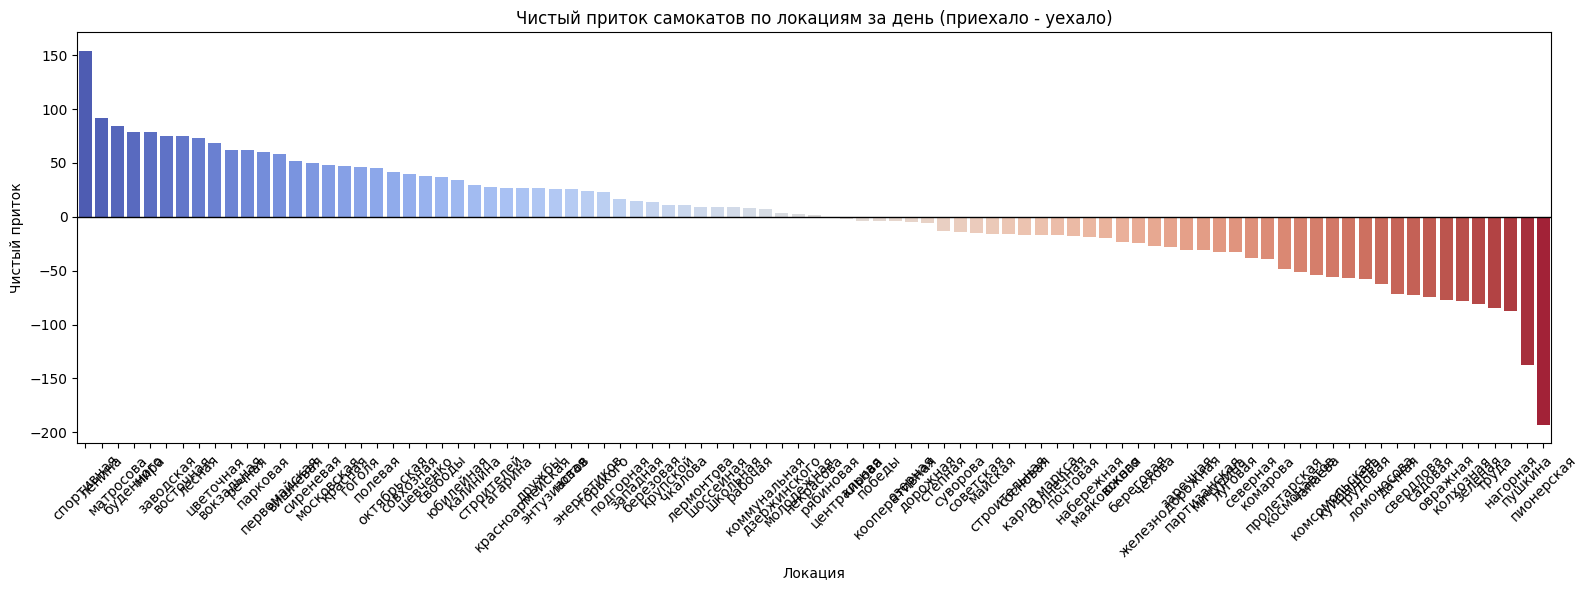

In [440]:
# Считаем количество уездов и приездов по каждой локации
departures = merged_df.groupby('Start Location').size().reset_index(name='departures')
arrivals = merged_df.groupby('End Location').size().reset_index(name='arrivals')

# Объединяем данные
balance = pd.merge(arrivals, departures, 
                   left_on='End Location', right_on='Start Location', 
                   how='outer')

# Заполняем пропуски нулями (если в локации были только приезды или только уезды)
balance['End Location'] = balance['End Location'].combine_first(balance['Start Location'])
balance = balance.drop(columns=['Start Location'])
balance = balance.rename(columns={'End Location': 'Location'})
balance['arrivals'] = balance['arrivals'].fillna(0)
balance['departures'] = balance['departures'].fillna(0)

# Считаем чистый приток
balance['net_flow'] = balance['arrivals'] - balance['departures']

# Сортировка по притоку
balance = balance.sort_values(by='net_flow', ascending=False)

# Визуализация
plt.figure(figsize=(16, 6))
sns.barplot(data=balance, x='Location', y='net_flow', palette='coolwarm')
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=45)
plt.title('Чистый приток самокатов по локациям за день (приехало - уехало)')
plt.ylabel('Чистый приток')
plt.xlabel('Локация')
plt.tight_layout()
plt.show()


In [451]:
balance[balance['net_flow'] >= 0]['net_flow'].sum()

1858

C:\Users\SIDov\AppData\Local\Temp\ipykernel_15444\650768839.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=final_distribution, x='Location', y='target_scooters', palette='viridis')


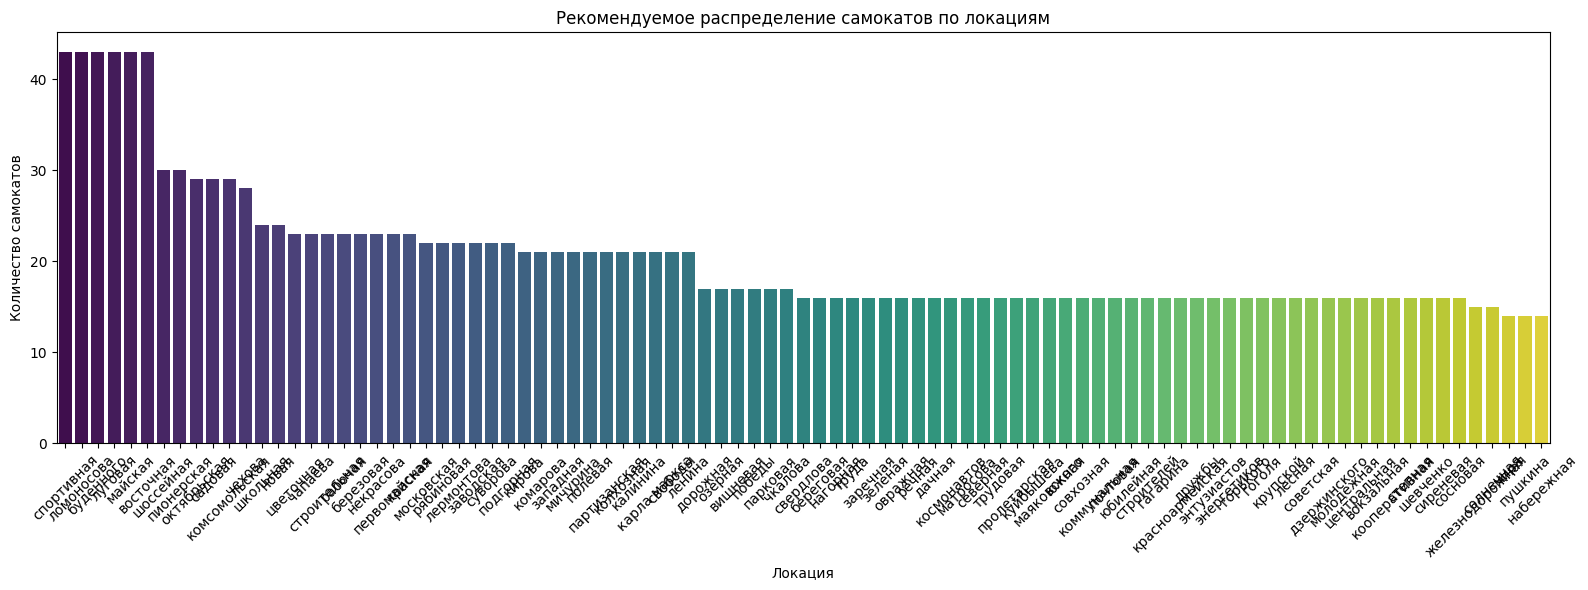

In [456]:
balance['total_traffic'] = balance['arrivals'] + balance['departures']

# Шаг 2: Посчитаем долю трафика каждой станции
balance['traffic_share'] = balance['total_traffic'] / balance['total_traffic'].sum()

# Шаг 3: Задаем общее количество самокатов (например, 1000)
total_scooters = balance[balance['net_flow'] >= 0]['net_flow'].sum()
balance['target_scooters'] = (balance['traffic_share'] * total_scooters).round().astype(int)

# Шаг 4: Подгоняем так, чтобы сумма была ровно равна total_scooters
diff = total_scooters - balance['target_scooters'].sum()
if diff != 0:
    # Добавляем или убавляем по одной штуке с самых трафиковых точек
    adjust_indices = balance['total_traffic'].sort_values(ascending=(diff < 0)).index[:abs(diff)]
    balance.loc[adjust_indices, 'target_scooters'] += np.sign(diff)

# Результат
final_distribution = balance[['Location', 'target_scooters']].sort_values(by='target_scooters', ascending=False)

# Визуализация
plt.figure(figsize=(16, 6))
sns.barplot(data=final_distribution, x='Location', y='target_scooters', palette='viridis')
plt.xticks(rotation=45)
plt.title('Рекомендуемое распределение самокатов по локациям')
plt.ylabel('Количество самокатов')
plt.xlabel('Локация')
plt.tight_layout()
plt.show()


In [459]:
final_distribution['target_scooters'].sum() == balance[balance['net_flow'] >= 0]['net_flow'].sum()

True

In [282]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd

# # Для каждого дня недели
# for weekday, df in average_samokat_to_weekdays:
#     # Создаём копию и сортируем по сумме 'inter' + 'leave'
#     df_sorted = df.copy()
#     df_sorted['total'] = df_sorted['inter'] + df_sorted['leave']
#     df_sorted = df_sorted.sort_values(by='total', ascending=False).drop(columns='total')

#     # Переводим в "длинный формат" для seaborn
#     df_melted = df_sorted[['inter', 'leave']].reset_index().melt(id_vars='Start Location', 
#                                                                  value_vars=['inter', 'leave'], 
#                                                                  var_name='Type', 
#                                                                  value_name='Value')

#     plt.figure(figsize=(18, 6))
#     sns.barplot(data=df_melted, x='Start Location', y='Value', hue='Type', palette='Set2')

#     plt.title(f'Inter и Leave — День недели {weekday}')
#     plt.xlabel('Улица')
#     plt.ylabel('Количество')
#     plt.xticks(rotation=90)
#     plt.legend(title='Тип')
#     plt.grid(axis='y')
#     plt.tight_layout()
#     plt.show()


In [417]:
# dat['Trip Cost'].mean()

In [418]:
# sum(dat['Trip Cost'])

In [419]:
# dat

In [420]:
# def street_traffic_share(weekday):
#     df = weekdays[weekday]
    
#     # Группировка по улице и подсчёт количества строк
#     street_counts = df.groupby('Start Location').size()
    
#     # Общий трафик за день (все строки)
#     total = street_counts.sum()
    
#     # Процентное соотношение
#     percentage = (street_counts / total * 100).sort_values(ascending=False)
    
#     return percentage.to_frame(name='percent')

# import matplotlib.pyplot as plt

# for i in range(7):
#     plt.figure(figsize=(10, 8))
    
#     df = street_traffic_share(i)
    
#     plt.barh(df.index, df['percent'], color='skyblue')
#     plt.title(f'Процент трафика по улицам — День {i}')
#     plt.xlabel('Процент от общего трафика')
#     plt.ylabel('Улица')
#     plt.gca().invert_yaxis()  # Самые большие сверху
#     plt.tight_layout()
#     plt.show()



In [421]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# plt.figure(figsize=(14, 10))
# df_day = merged_df

# plt.subplot(4, 2, i + 1)
# sns.histplot(df_day['Trip Cost'], bins=30, kde=True, color='mediumseagreen')
# plt.title(f'Распределение Trip Cost — День {i}')
# plt.xlabel('Trip Cost')
# plt.ylabel('Количество')
# plt.grid(True)

# plt.tight_layout()
# plt.show()

In [422]:
# df_day['Trip Cost'].median()

In [423]:
# df_day['Trip Cost'].mean()

In [424]:
# df_day['Trip Cost'].mode()

In [136]:
# reversed_dict = {}
# for k, v in grouped_streets_by_district.drop(columns=['1']).to_dict()['Start Location'].items():
#     for v1 in v:
#         reversed_dict[v1] = k

# all_trafic['district'] = all_trafic.index
# all_trafic['district'] = all_trafic['district'].apply(lambda x: reversed_dict[x])

In [137]:
# reversed_dict

In [138]:
# all_trafic

In [139]:
# all_trafic = all_trafic.groupby('district')[['inter', 'leave', 'turn_per_day']].agg('sum').sort_values(by='turn_per_day', ascending=False)

In [140]:
# merged_df.groupby('Start District')['Promo'].agg('sum').to_frame().sort_values(by='Promo', ascending=False)

In [141]:
# testing = merged_df.copy()

In [142]:
# testing = testing[testing['Start District'] == testing['End District']].groupby('Start District')['End District'].agg('count').to_frame().sort_values(by='End District', ascending=False)

In [143]:
# all_trafic

In [144]:
# testing['district'] = testing.index
# all_trafic['district'] = all_trafic.index

In [145]:
# testing.sort_values(by='End District', ascending=False)

In [146]:
# testing = testing.reset_index()
# all_trafic = all_trafic.reset_index()

# # Теперь можно выполнить merge
# t = testing.merge(all_trafic, on='district')

In [147]:
# all_trafic.index.name = 'Start District'

In [148]:
# t.drop(columns=['index', 'Start District_x', 'Start District_y'])

In [149]:
# merged_df.columns

In [150]:
# merged_df.columns

In [151]:
# all_trafic

In [425]:
# (
#     weekdays[0]
#     .groupby('Promo')
#     .apply(lambda x: x)
#     .loc[1]
#     .groupby('Start Location')['Start Location']
#     .agg('count')
#     .sort_values(ascending=False)  # <-- сортировка по убыванию
#     .to_frame(name='count')        # <-- имя колонки для наглядности
# )


In [426]:
# target_streets = ['буденного', 'восточная', 'майская', 'ломоносова', 'спортивная', 'луговая']
# day_order = list(range(7))  # Понедельник = 0, Воскресенье = 6

In [427]:
# merged_df.columns

In [428]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Функция для расчета среднего трафика по часам
# def get_hourly_avg_clean(df, street, direction):
#     col = 'Start Location' if direction == 'leave' else 'End Location'
    
#     df = df.copy()
#     df['weekday'] = df['weekday'].astype(int)

#     filtered = df[df[col] == street]
    
#     grouped = filtered.groupby(['weekday', 'Start Hour']).size().reset_index(name='count')
#     total_per_day = grouped.groupby('weekday')['count'].transform('sum')
#     grouped['normalized_count'] = grouped['count'] / total_per_day
    
#     all_combinations = pd.MultiIndex.from_product(
#         [list(map(int, day_order)), range(24)],
#         names=['weekday', 'Start Hour']
#     ).to_frame(index=False)
    
#     merged = all_combinations.merge(
#         grouped, 
#         on=['weekday', 'Start Hour'], 
#         how='left'
#     ).fillna({'normalized_count': 0, 'count': 0})
    
#     merged['street'] = street
#     merged['direction'] = direction
#     return merged


# # Собираем данные
# hourly_data_clean = pd.concat([
#     get_hourly_avg_clean(merged_df, street, direction) 
#     for street in target_streets 
#     for direction in ['leave', 'arrive']
# ])

# # # Строим графики по дням недели
# # for day in day_order:
# #     plt.figure(figsize=(18, 8))
# #     data_day = hourly_data_clean[hourly_data_clean['Days'] == day]
    
# #     # Проверяем, есть ли данные для этого дня
# #     if len(data_day) == 0:
# #         print(f"Нет данных для дня {day}")
# #         continue
    
# #     # Используем normalized_count вместо count
# #     sns.lineplot(
# #         data=data_day,
# #         x='Start Hour',
# #         y='normalized_count',
# #         hue='street',
# #         style='direction',
# #         markers=True,
# #         dashes=False,
# #         palette='tab10'
# #     )
    
# #     # Настройки графика
# #     day_names = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']
# #     plt.title(f'Нормализованное количество уездов и приездов по часам — {day_names[day]}')
# #     plt.xlabel('Час')
# #     plt.ylabel('Доля поездок от общего количества за день')
# #     plt.xticks(range(24))
# #     plt.grid(True)
# #     plt.legend(title='Улица и направление', bbox_to_anchor=(1.05, 1), loc='upper left')
# #     plt.tight_layout()
# #     plt.show()

In [429]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from itertools import combinations
# import numpy as np

# # Функция для создания более темного оттенка цвета
# def darken_color(color, factor=0.3):
#     color = np.array(color)
#     return np.clip(color * (1 - factor), 0, 1)

# # Функция для построения графиков для пар улиц — отдельно приезды и уезды
# def plot_all_streets_on_one_chart(data, day):
#     day_names = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']
    
#     for direction in ['arrive', 'leave']:
#         plt.figure(figsize=(18, 8))
        
#         # Фильтруем по направлению
#         direction_data = data[data['direction'] == direction]
        
#         # Строим график
#         sns.lineplot(
#             data=direction_data,
#             x='Start Hour',
#             y='normalized_count',
#             hue='street',
#             style='street',
#             dashes=False,
#             palette='tab10',
#             linewidth=2
#         )

#         # Оформление
#         direction_ru = 'приездов' if direction == 'arrive' else 'уездов'
#         plt.title(f'Нормализованное количество {direction_ru} по часам — {day_names[day]} (все улицы)')
#         plt.xlabel('Час')
#         plt.ylabel('Доля поездок от общего количества за день')
#         plt.xticks(range(24))
#         plt.grid(True)
#         plt.legend(title='Улица', bbox_to_anchor=(1.05, 1), loc='upper left')
#         plt.tight_layout()
#         plt.show()


# for day in day_order:
#     data_day = hourly_data_clean[hourly_data_clean['weekday'] == day]
    
#     if len(data_day) == 0:
#         print(f"Нет данных для дня {day}")
#         continue
    
#     plot_all_streets_on_one_chart(data_day, day)